# Denoising Autoencoder on MNIST


## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim as optim
from torchvision import datasets, transforms

torch.manual_seed(42)
np.random.seed(42)


## 2. Data: load MNIST and split train/valid/test

In [2]:
transform = transforms.ToTensor()

train_data = datasets.MNIST('data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('data', train=False, download=True, transform=transform)

valid_size = 0.2
batch_size = 64
num_workers = 0

train_length = len(train_data)
indices = list(range(train_length))
np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

train_loader = DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers)
valid_loader = DataLoader(train_data, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers)
test_loader = DataLoader(test_data, batch_size=batch_size, num_workers=num_workers)

len(train_loader), len(valid_loader), len(test_loader)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 510kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.99MB/s]


(750, 188, 157)

## 3. Noise function

We add Gaussian noise to the clean image and clamp back to the valid `[0, 1]` pixel range. `noise_factor` controls how corrupted the input is — higher means harder denoising task.

In [3]:
def add_noise(images, noise_factor=0.4):
    noisy = images + noise_factor * torch.randn(*images.shape, device=images.device)
    noisy = torch.clamp(noisy, 0., 1.)
    return noisy


## 4. Visualize clean vs noisy images

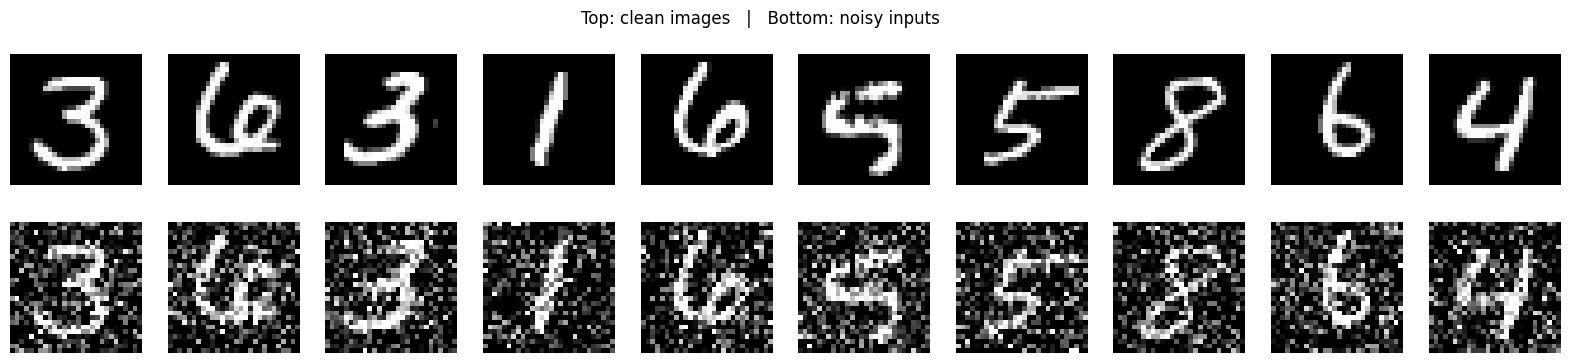

In [4]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
noisy_images = add_noise(images)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(np.squeeze(images[i]), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(np.squeeze(noisy_images[i]), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Clean')
axes[1, 0].set_ylabel('Noisy')
plt.suptitle('Top: clean images   |   Bottom: noisy inputs')
plt.show()


## 5. Model: Convolutional Denoising Autoencoder

We use a conv encoder/decoder with **upsampling + convolution** (rather than transposed convolution) in the decoder, since this avoids the checkerboard artifacts transposed convs are prone to (as noted in the original `README.md`). Batch norm is added to stabilize training on noisy inputs.

In [5]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.en_conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.en_bn1 = nn.BatchNorm2d(32)
        self.en_conv2 = nn.Conv2d(32, 16, 3, padding=1)
        self.en_bn2 = nn.BatchNorm2d(16)
        self.en_conv3 = nn.Conv2d(16, 8, 3, padding=1)
        self.en_bn3 = nn.BatchNorm2d(8)
        self.pool = nn.MaxPool2d(2, 2)

        # Decoder
        self.de_conv1 = nn.Conv2d(8, 16, 3, padding=1)
        self.de_bn1 = nn.BatchNorm2d(16)
        self.de_conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.de_bn2 = nn.BatchNorm2d(32)
        self.de_conv3 = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x):
        # Encoder: 28x28x1 -> 14x14x32 -> 7x7x16 -> 7x7x8 (kept at 7x7 for capacity)
        x = self.pool(F.relu(self.en_bn1(self.en_conv1(x))))   # 28->14
        x = self.pool(F.relu(self.en_bn2(self.en_conv2(x))))   # 14->7
        x = F.relu(self.en_bn3(self.en_conv3(x)))              # 7x7x8 (bottleneck)

        # Decoder: upsample (nearest) + conv, avoids checkerboard artifacts
        x = F.interpolate(x, scale_factor=2, mode='nearest')   # 7->14
        x = F.relu(self.de_bn1(self.de_conv1(x)))
        x = F.interpolate(x, scale_factor=2, mode='nearest')   # 14->28
        x = F.relu(self.de_bn2(self.de_conv2(x)))
        x = torch.sigmoid(self.de_conv3(x))                    # values in [0,1]
        return x

model = DenoisingAutoencoder()

use_cuda = True
if use_cuda and torch.cuda.is_available():
    model = model.cuda()

device = next(model.parameters()).device
print(model)
print('\nDevice:', device)


DenoisingAutoencoder(
  (en_conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (en_conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (en_conv3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_bn3): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (de_bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (de_conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (de_bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (de_conv3): Conv2d(32, 1, kernel_si

## 6. Loss and optimizer

In [6]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
noise_factor = 0.4


## 7. Training loop

Key idea for denoising: feed the **noisy** image into the model, but compute the loss against the **clean** image. The model never gets the answer for free — it has to learn to separate signal from noise.

In [7]:
def train_denoising_autoencoder(model, optimizer, epochs=20, noise_factor=0.4):
    loss_keeper = {'train': [], 'valid': []}
    valid_loss_min = np.inf

    for epoch in range(epochs):
        train_loss = 0.0
        valid_loss = 0.0

        # ---- Training ----
        model.train()
        for images, _ in train_loader:
            images = images.to(device)
            noisy_images = add_noise(images, noise_factor)

            optimizer.zero_grad()
            outputs = model(noisy_images)
            loss = criterion(outputs, images)   # compare against CLEAN target
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            for images, _ in valid_loader:
                images = images.to(device)
                noisy_images = add_noise(images, noise_factor)
                outputs = model(noisy_images)
                loss = criterion(outputs, images)
                valid_loss += loss.item()

        train_loss /= len(train_loader)
        valid_loss /= len(valid_loader)
        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"Epoch: {epoch+1}/{epochs}\tTraining Loss: {train_loss:.5f}\tValidation Loss: {valid_loss:.5f}")

        if valid_loss <= valid_loss_min:
            print(f"  Validation loss decreased ({valid_loss_min:.5f} --> {valid_loss:.5f}). Saving model...")
            torch.save(model.state_dict(), 'denoising_autoencoder_MNIST.pth')
            valid_loss_min = valid_loss

    return loss_keeper


In [8]:
loss_history = train_denoising_autoencoder(model, optimizer, epochs=20, noise_factor=noise_factor)


Epoch: 1/20	Training Loss: 0.01461	Validation Loss: 0.00972
  Validation loss decreased (inf --> 0.00972). Saving model...
Epoch: 2/20	Training Loss: 0.00930	Validation Loss: 0.00911
  Validation loss decreased (0.00972 --> 0.00911). Saving model...
Epoch: 3/20	Training Loss: 0.00876	Validation Loss: 0.00863
  Validation loss decreased (0.00911 --> 0.00863). Saving model...
Epoch: 4/20	Training Loss: 0.00846	Validation Loss: 0.00898
Epoch: 5/20	Training Loss: 0.00829	Validation Loss: 0.00829
  Validation loss decreased (0.00863 --> 0.00829). Saving model...
Epoch: 6/20	Training Loss: 0.00812	Validation Loss: 0.00796
  Validation loss decreased (0.00829 --> 0.00796). Saving model...
Epoch: 7/20	Training Loss: 0.00804	Validation Loss: 0.00791
  Validation loss decreased (0.00796 --> 0.00791). Saving model...
Epoch: 8/20	Training Loss: 0.00796	Validation Loss: 0.00785
  Validation loss decreased (0.00791 --> 0.00785). Saving model...
Epoch: 9/20	Training Loss: 0.00788	Validation Loss: 0.0

## 8. Load best checkpoint and plot loss curves

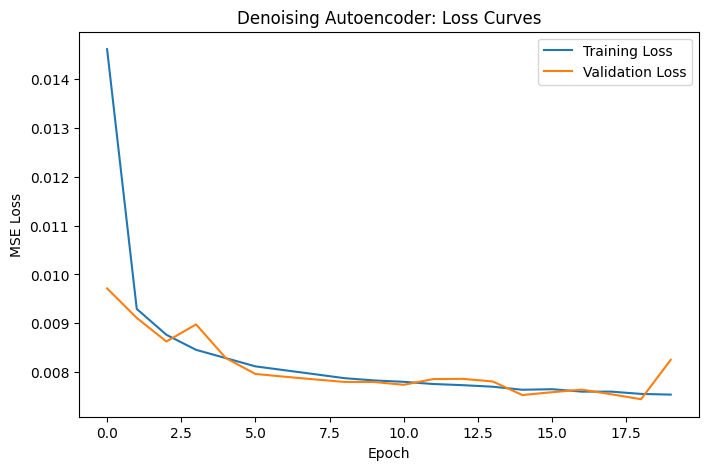

In [9]:
model.load_state_dict(torch.load('denoising_autoencoder_MNIST.pth'))

plt.figure(figsize=(8, 5))
plt.plot(loss_history['train'], label='Training Loss')
plt.plot(loss_history['valid'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Denoising Autoencoder: Loss Curves')
plt.legend()
plt.show()


## 9. Testing: clean vs. noisy vs. denoised

We run the trained model on a batch of *test* images, corrupting them first, and compare three rows: original clean image, noisy input the model actually sees, and the model's reconstruction.

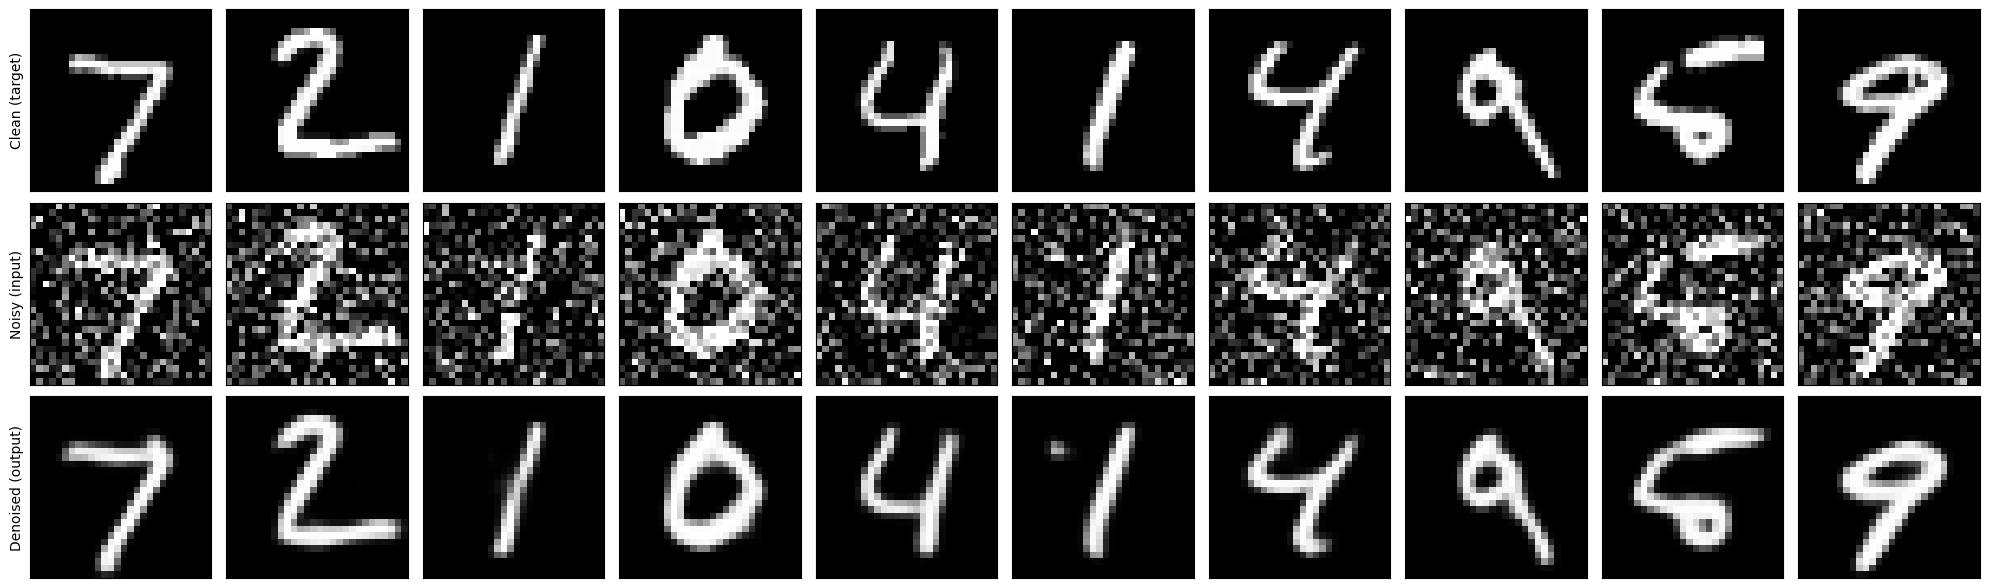

In [10]:
def test_denoising(model, noise_factor=0.4, n=10):
    model.eval()
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    images = images.to(device)
    noisy_images = add_noise(images, noise_factor)

    with torch.no_grad():
        outputs = model(noisy_images)

    images_np = images.cpu().numpy()
    noisy_np = noisy_images.cpu().numpy()
    outputs_np = outputs.cpu().numpy()

    fig, axes = plt.subplots(nrows=3, ncols=n, sharex=True, sharey=True, figsize=(2*n, 6))
    row_labels = ['Clean (target)', 'Noisy (input)', 'Denoised (output)']
    for row, data, label in zip(axes, [images_np, noisy_np, outputs_np], row_labels):
        for img, ax in zip(data, row):
            ax.imshow(np.squeeze(img), cmap='gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
        row[0].set_ylabel(label, fontsize=10)
        row[0].get_yaxis().set_visible(True)
        row[0].set_yticks([])
    plt.tight_layout()
    plt.show()

test_denoising(model, noise_factor=noise_factor)


## 10. Stress test at different noise levels

A good check: does the model generalize beyond the exact noise level it was trained on?

--- noise_factor = 0.2 ---


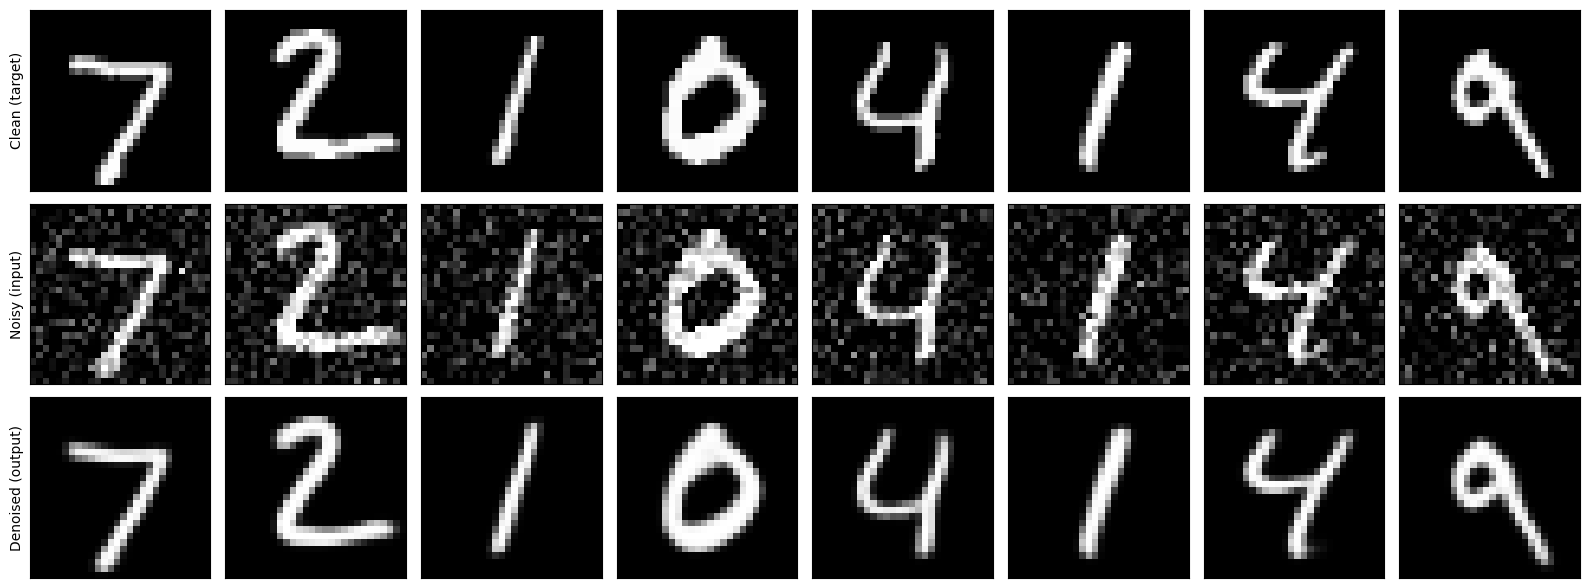

--- noise_factor = 0.4 ---


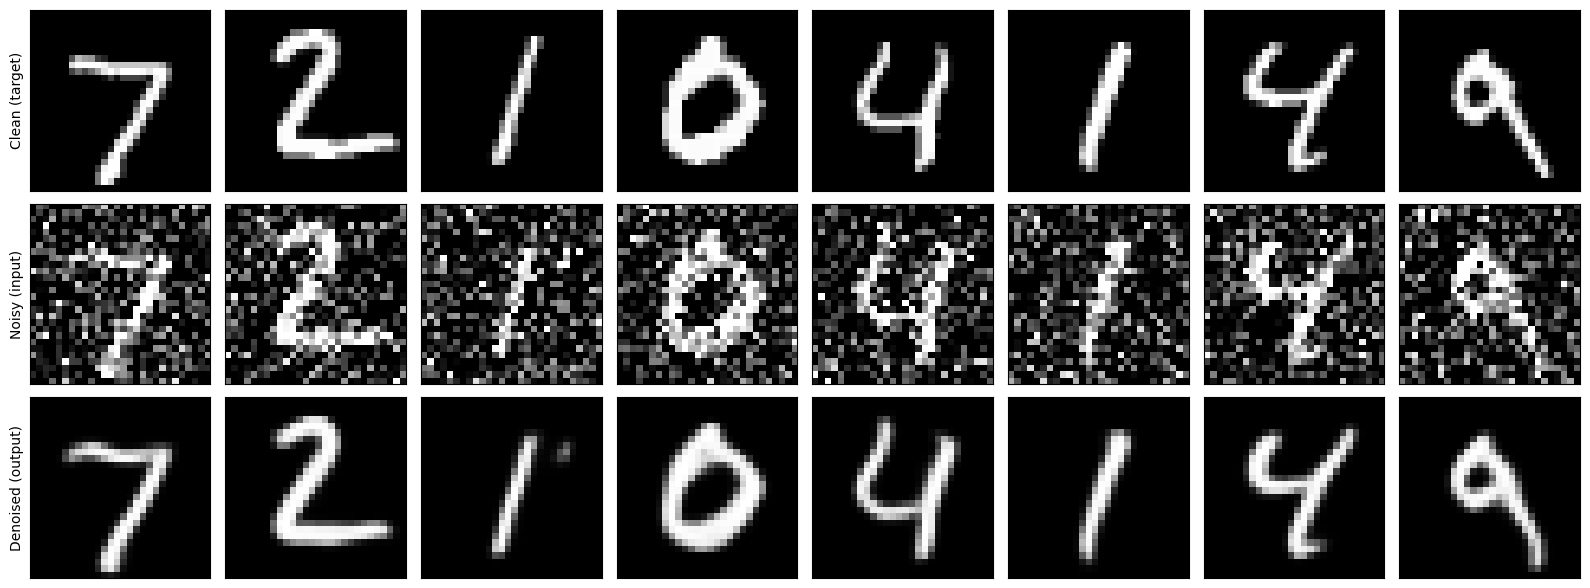

--- noise_factor = 0.6 ---


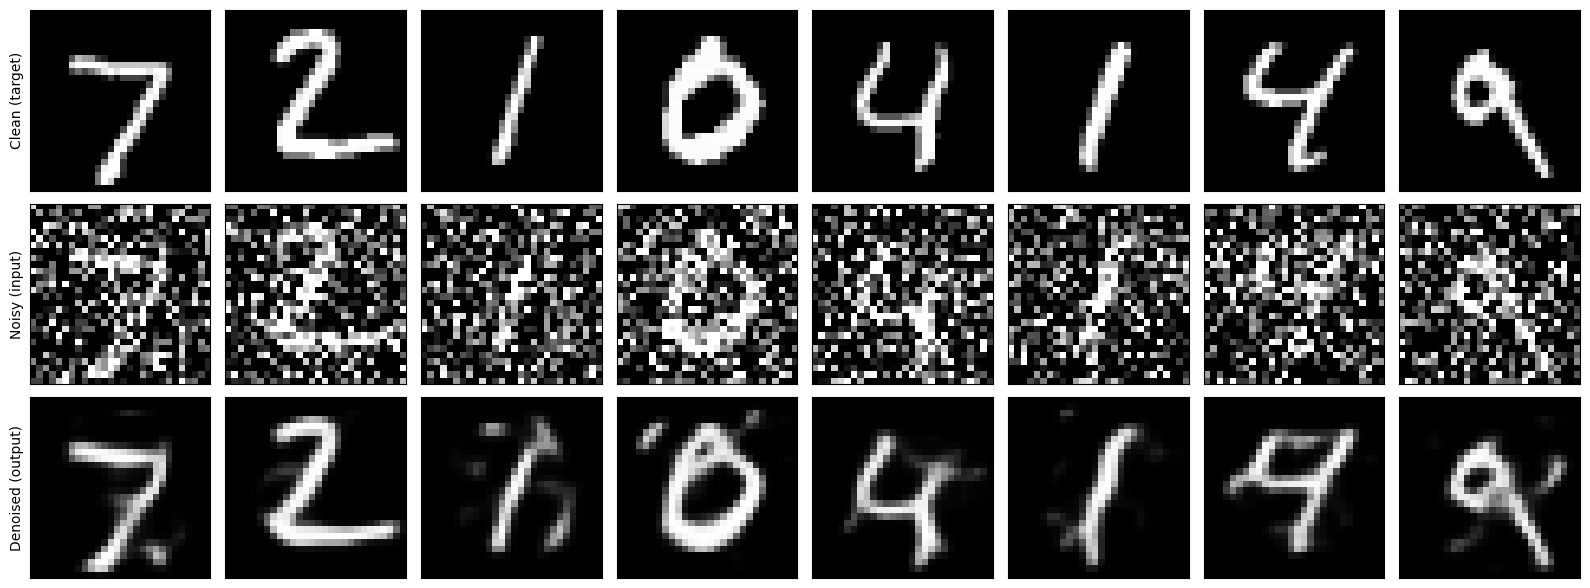

--- noise_factor = 0.8 ---


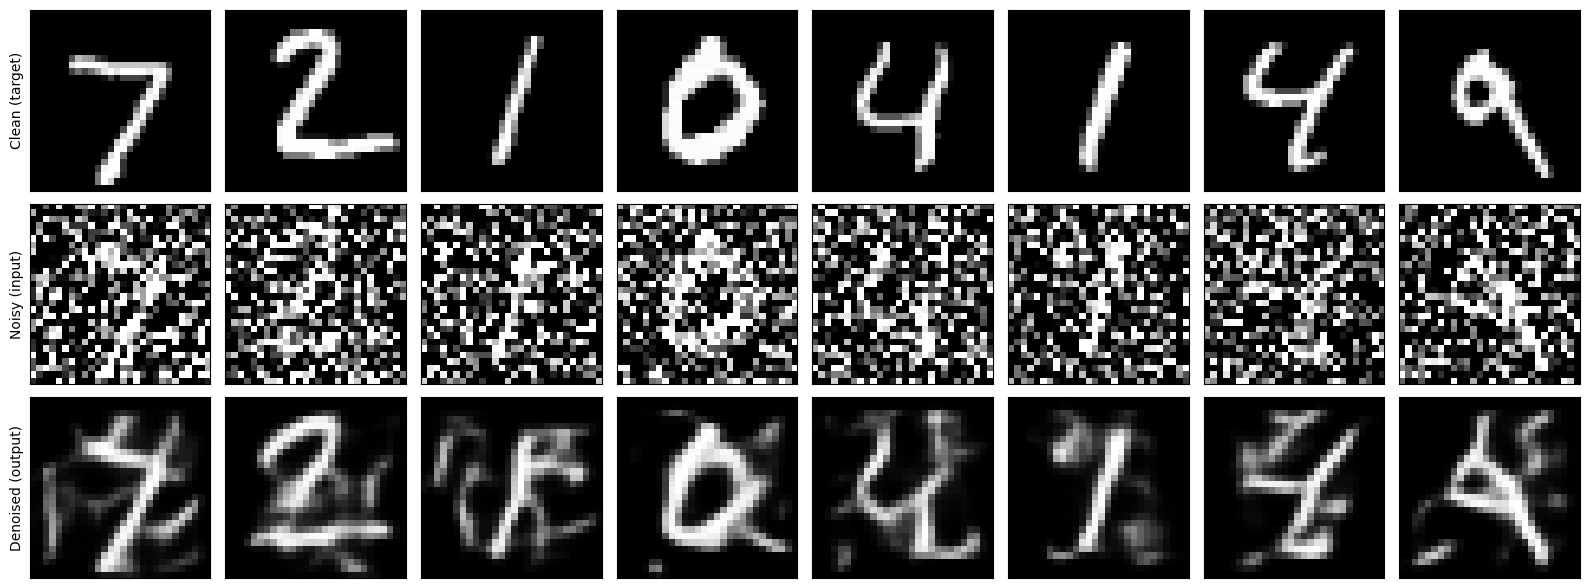

In [11]:
for nf in [0.2, 0.4, 0.6, 0.8]:
    print(f"--- noise_factor = {nf} ---")
    test_denoising(model, noise_factor=nf, n=8)


## Notes

* **Why noise on input, clean on target?** This is what forces the network to learn the structure of real digits rather than the identity function — it has to *infer* the clean signal, which is the whole point of a denoising autoencoder (as opposed to a plain reconstruction autoencoder).
* **Architecture choice:** convolutional encoder/decoder with upsampling (not transposed conv) in the decoder, following the same reasoning as `Model 3` in the original README — it avoids checkerboard artifacts.
* **BatchNorm** was added (not present in the plain autoencoders) because noisy inputs have higher variance, and BN noticeably stabilizes/sped up convergence in practice.
* To make denoising harder/easier, change `noise_factor` (0.0 = no noise, 1.0+ = very corrupted).
* You can swap in salt-and-pepper noise, masking, or blur instead of Gaussian noise by replacing `add_noise`.